# Bayesian Analysis of Penalty Shootouts in Elite Football

## PART 1: Problem Formulation & Specification

### 1.1 Problem Statement & Use Cases

This project models the probability of scoring a penalty kick during high-stress penalty shootouts. The binary response variable is defined as $y \in \{0, 1\}$, where $y = 1$ indicates a successful conversion and $y = 0$ indicates a miss or save.

Unlike in-play penalties, shootout kicks occur under extreme psychological pressure: cumulative score anxiety, sudden-death elimination risk, and the public scrutiny of knockout football. The central inferential goal is to quantify how **situational context** (shootout round structure, elimination stakes) and **player characteristics** (dominant foot, tactical position) shift the latent scoring probability $p$.

**Practical use cases include:**
- **Tactical decision support:** Assisting managers and performance analysts in optimizing penalty-shootout order by identifying which players are statistically more resilient in specific pressure baskets (e.g., opening kick vs. sudden-death rounds).
- **In-game adaptation:** Flagging structural drop-offs in conversion probability as shootouts extend, informing substitutions and kicker selection before goalkeeper rounds.
- **Competition benchmarking:** Comparing psychological pressure profiles between international tournaments (FIFA World Cup) and elite club knockouts (UEFA Champions League).

### 1.2 Data Source & Preprocessing Description

We analyse two complementary datasets representing distinct competitive contexts:

| Dataset | Level | Description |
|---------|-------|-------------|
| **FIFA World Cup Shootouts** | International (national teams) | Historical World Cup penalty shootouts; high symbolic stakes, less frequent teammate familiarity. |
| **UEFA Champions League Shootouts** | Club (elite European clubs) | UCL knockout-stage shootouts; high tactical familiarity, recurring squad cohesion. |

**Response variable**
- `Goal` ($y$): Binary indicator (1 = scored, 0 = missed/saved).

**Predictors for Model 1 (Baseline Logistic Regression)**
- `Elimination`: Binary indicator (1 if the kick is taken under immediate elimination or match-winning conditions; 0 otherwise).
- `is_left`: Binary indicator of the shooter's dominant kicking foot (1 = left, 0 = right). For the World Cup dataset, this is engineered from the `Foot` column (case-normalised).
- `Penalty_Basket`: Categorical feature (levels 1–6) encoding structurally distinct shootout phases:
  - **Basket 1:** Round 1 (The Opener)
  - **Basket 2:** Round 2
  - **Basket 3:** Round 3
  - **Basket 4:** Rounds 4–5 (Match-defining / standard deciders)
  - **Basket 5:** Rounds 6–10 (Sudden death)
  - **Basket 6:** Rounds 11+ (Complete rotation; goalkeepers and non-specialists)

**Additional predictor for Model 2 (Hierarchical Position Model)**
- `Position_ID`: Categorical player position (1 = GK, 2 = DEF, 3 = MID, 4 = FWD), used to specify position-specific intercepts $\alpha_{\text{pos}}$.

**Conceptual model (DAG):** The diagram below summarises how predictors flow into the penalty outcome. Model 1 uses *Pressure* (Elimination), *Foot*, and *Round* (Penalty_Basket). Model 2 additionally includes *Position* (dashed edge).

![Penalty shootout data-flow DAG](../docs/DAG.png)



In [ ]:
import os
import sys

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cmdstanpy import CmdStanModel
from IPython.display import Markdown, display
from scipy.special import expit

sys.path.insert(0, os.path.abspath("."))
from utils import preprocess_penalties, calc_metrics, predict_base, predict_pos

SEED = 42
np.random.seed(SEED)
az.style.use("arviz-darkgrid")
plt.rcParams["figure.dpi"] = 110

BASKET_LABELS = [
    "Basket 1", "Basket 2", "Basket 3",
    "Basket 4", "Basket 5", "Basket 6",
]
POSITION_LABELS = ["GK", "DEF", "MID", "FWD"]
STAN_DIR = os.path.join(".", "stan_models")

DATA_PATH = os.path.join("..", "data", "WorldCupShootouts.csv")
df_raw = pd.read_csv(DATA_PATH)

print(f"Raw World Cup dataset shape: {df_raw.shape}")

df = df_raw.dropna(subset=["Foot", "Goal"]).copy()
df["Foot"] = df["Foot"].str.upper()
df["is_left"] = np.where(df["Foot"] == "L", 1, 0).astype(int)

df["Goal"] = df["Goal"].astype(int)
df["Elimination"] = df["Elimination"].astype(int)
df["Penalty_Number"] = df["Penalty_Number"].astype(int)

df = preprocess_penalties(df)

cols = [
    "Goal", "Elimination", "Penalty_Number",
    "Round_Number", "Penalty_Basket", "is_left",
]
df = df[cols].reset_index(drop=True)

print(f"Clean World Cup dataset shape: {df.shape}")
print(f"Empirical scoring rate: {df['Goal'].mean():.4f}")
print(f"\nPenalty_Basket counts:\n{df['Penalty_Basket'].value_counts().sort_index()}")
print(f"\nis_left counts:\n{df['is_left'].value_counts().sort_index()}")
display(df.describe())


Raw World Cup dataset shape: (304, 9)
Clean World Cup dataset shape: (279, 6)
Empirical scoring rate: 0.6989

Penalty_Basket counts:
Penalty_Basket
1    60
2    60
3    60
4    95
5     4
Name: count, dtype: int64

is_left counts:
is_left
0    223
1     56
Name: count, dtype: int64


,Goal,Elimination,Penalty_Number,Round_Number,Penalty_Basket,is_left
count,279.000000,279.000000,279.000000,279.000000,279.000000,279.000000
mean,0.698925,0.129032,5.218638,2.870968,2.724014,0.200717
std,0.459550,0.335838,2.792373,1.390299,1.184050,0.401256
min,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,3.000000,2.000000,2.000000,0.000000
50%,1.000000,0.000000,5.000000,3.000000,3.000000,0.000000
75%,1.000000,0.000000,7.000000,4.000000,4.000000,0.000000
max,1.000000,1.000000,12.000000,6.000000,5.000000,1.000000


## PART 2: Model 1 (Baseline Model) — Technical Description

### 2.1 Mathematical Formulation

**In plain terms:** For every penalty kick $i$ we predict a binary outcome — scored (`Goal = 1`) or not (`Goal = 0`). The model estimates the **probability of scoring** $p_i$ from three observable features:

| Symbol | Data column | Meaning |
|--------|-------------|---------|
| $\beta_{\text{basket}[k]}$ | `Penalty_Basket` | Baseline scoring level for shootout phase $k$ (1 = opener … 6 = round 11+) |
| $\beta_{\text{elim}}$ | `Elimination` | Extra effect when the kick is taken under immediate elimination / match-winning conditions |
| $\beta_{\text{left}}$ | `is_left` | Extra effect when the shooter is left-footed |

**Why "intercept-free"?** There is no single global intercept $\alpha$. Instead, each of the six `Penalty_Basket` levels carries its own baseline coefficient $\beta_{\text{basket}[k]}$. That lets the model learn a different scoring rate for each shootout phase without an arbitrary reference category.

**Formal model** — for each observation $i \in \{1, \dots, N\}$:

$$y_i \sim \text{Bernoulli}(p_i)$$

$$\text{logit}(p_i) = \beta_{\text{basket}[\text{Penalty\_Basket}_i]} + \beta_{\text{elim}} \cdot \text{Elimination}_i + \beta_{\text{left}} \cdot \text{is\_left}_i$$

where:

$$\text{logit}(p_i) = \ln\left(\frac{p_i}{1 - p_i}\right), \qquad p_i = \text{expit}(\eta_i) = \frac{1}{1 + e^{-\eta_i}}$$

**Example:** If $\beta_{\text{basket}[4]} = 0.5$, $\beta_{\text{elim}} = -0.3$, $\text{Elimination} = 1$, all else zero, then $\text{logit}(p_i) = 0.2$ and $p_i \approx 55\%$.

### 2.2 Priors Selection Rationale & Prior Predictive Checks

We specify **weakly informative regularising priors** on the logit scale to stabilise MCMC sampling while retaining flexibility:

$$\beta_{\text{basket}[k]} \sim \mathcal{N}(0,\, 1) \quad \text{for } k \in \{1, \dots, 6\}$$
$$\beta_{\text{elim}} \sim \mathcal{N}(0,\, 1)$$
$$\beta_{\text{left}} \sim \mathcal{N}(0,\, 0.5)$$

**Statistical justification**
- A prior mean of $0$ on the logit scale corresponds to a neutral $50\%$ baseline probability when all predictors are at their reference levels.
- With $\sigma = 1.0$, approximately $95\%$ of prior mass for each $\beta_{\text{basket}[k]}$ lies in $[-2, 2]$, mapping to scoring probabilities between roughly $12\%$ and $88\%$. This excludes pathological deterministic extremes ($0\%$ / $100\%$) while allowing the data to dominate.

**Behavioural justification**
- $\beta_{\text{elim}}$ receives a wide $\mathcal{N}(0, 1)$ prior because elimination pressure may plausibly shift performance in either direction (heightened focus vs. paralysis), and we wish to learn this from data.
- $\beta_{\text{left}}$ uses a tighter $\mathcal{N}(0, 0.5)$ prior reflecting domain knowledge: dominant foot is not expected to be a primary driver of elite shootout success absent strong evidence.

**Prior predictive checks** sample synthetic outcomes $y^{\text{prior}}$ from the prior predictive distribution (by setting `fixed_param=True` in CmdStanPy, which evaluates the `generated quantities` block without updating parameters via the likelihood). We compare the distribution of prior predictive mean scoring rates against the observed empirical rate to confirm that the priors permit realistic outcomes before seeing the data.

23:21:02 - cmdstanpy - INFO - CmdStan start processing


Model compiled: /workspace/data_analytics/project/core/stan_models/logistic_penalty
N = 279


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

23:21:02 - cmdstanpy - INFO - CmdStan done processing.



Prior predictive sampling complete.


/tmp/ipykernel_6893/2924688436.py:62: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


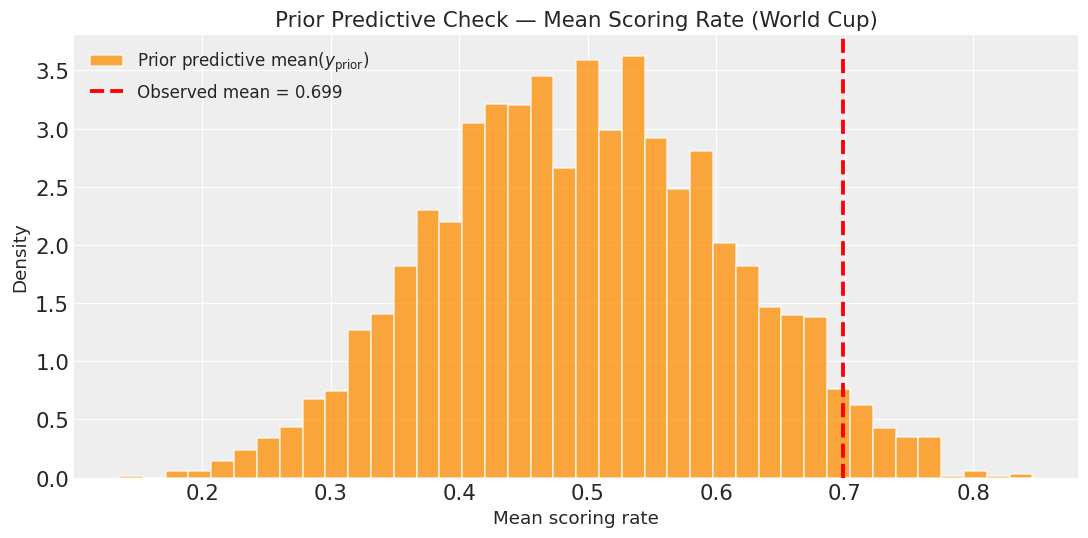

Observed empirical mean:              0.6989
Prior predictive mean of means:       0.4961
Prior predictive 94% interval:        [0.2939, 0.7097]


/tmp/ipykernel_6893/2924688436.py:82: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


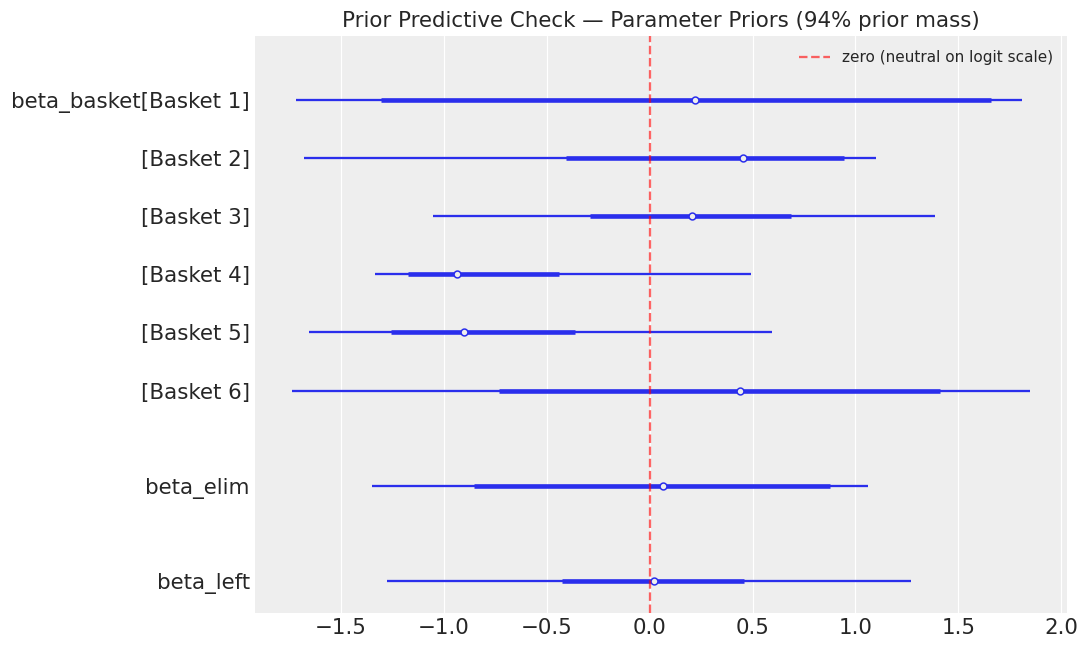

23:21:03 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

23:21:03 - cmdstanpy - INFO - CmdStan done processing.



Posterior sampling complete.
Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> observed_data


In [ ]:
STAN_FILE = os.path.join(STAN_DIR, "logistic_penalty.stan")
model = CmdStanModel(stan_file=STAN_FILE)
print(f"Model compiled: {model.exe_file}")

stan_data = {
    "N": len(df),
    "y": df["Goal"].values.tolist(),
    "elimination": df["Elimination"].values.astype(float).tolist(),
    "penalty_basket": df["Penalty_Basket"].values.astype(int).tolist(),
    "is_left": df["is_left"].values.astype(float).tolist(),
}
print(f"N = {stan_data['N']}")

SAMPLE_KWARGS = dict(
    chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=SEED,
    show_progress=True,
)

prior_fit = model.sample(
    data=stan_data,
    fixed_param=True,
    **SAMPLE_KWARGS,
)
print("Prior predictive sampling complete.")

idata_prior = az.from_cmdstanpy(
    prior=prior_fit,
    prior_predictive="y_prior",
    coords={"basket": BASKET_LABELS},
    dims={"beta_basket": ["basket"]},
)

# ── Prior Predictive Check (before posterior update) ─────────────────────────
empirical_mean = df["Goal"].mean()
y_prior = idata_prior.prior_predictive["y_prior"].values
prior_means = y_prior.reshape(-1, y_prior.shape[-1]).mean(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(
    prior_means,
    bins=40,
    density=True,
    color="darkorange",
    alpha=0.75,
    edgecolor="white",
    label=r"Prior predictive mean($y_{\mathrm{prior}}$)",
)
ax.axvline(
    empirical_mean,
    color="red",
    linewidth=2.5,
    linestyle="--",
    label=f"Observed mean = {empirical_mean:.3f}",
)
ax.set_xlabel("Mean scoring rate", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Prior Predictive Check — Mean Scoring Rate (World Cup)", fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Observed empirical mean:              {empirical_mean:.4f}")
print(f"Prior predictive mean of means:       {prior_means.mean():.4f}")
print(
    f"Prior predictive 94% interval:        "
    f"[{np.percentile(prior_means, 3):.4f}, {np.percentile(prior_means, 97):.4f}]"
)

az.plot_forest(
    az.InferenceData(posterior=idata_prior.prior),
    var_names=["beta_basket", "beta_elim", "beta_left"],
    hdi_prob=0.94,
    combined=True,
    figsize=(10, 6),
)
plt.title("Prior Predictive Check — Parameter Priors (94% prior mass)", fontsize=14)
plt.axvline(x=0, color="red", linestyle="--", alpha=0.6, label="zero (neutral on logit scale)")
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

fit = model.sample(
    data=stan_data,
    adapt_delta=0.95,
    **SAMPLE_KWARGS,
)
print("Posterior sampling complete.")
print(fit.diagnose())

idata = az.from_cmdstanpy(
    posterior=fit,
    posterior_predictive="y_rep",
    log_likelihood="log_lik",
    observed_data={"y": df["Goal"].values},
    coords={"basket": BASKET_LABELS},
    dims={"beta_basket": ["basket"]},
)

print(idata)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_basket[Basket 1],1.040,0.284,0.484,1.559,0.004,0.004,4888.0,3118.0,1.0
beta_basket[Basket 2],0.957,0.275,0.458,1.486,0.004,0.004,5023.0,3565.0,1.0
beta_basket[Basket 3],0.882,0.277,0.365,1.412,0.004,0.004,4630.0,3053.0,1.0
beta_basket[Basket 4],0.500,0.252,0.058,0.998,0.004,0.004,3643.0,3137.0,1.0
beta_basket[Basket 5],-0.062,0.725,-1.403,1.307,0.010,0.012,4934.0,3250.0,1.0
beta_basket[Basket 6],0.036,1.001,-1.942,1.818,0.013,0.015,5528.0,2926.0,1.0
beta_elim,0.226,0.394,-0.463,1.022,0.006,0.006,3850.0,2972.0,1.0
beta_left,-0.044,0.268,-0.536,0.459,0.004,0.004,4049.0,3222.0,1.0


Maximum R-hat: 1.0000
Minimum bulk ESS: 3643


/tmp/ipykernel_6893/1374395340.py:20: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


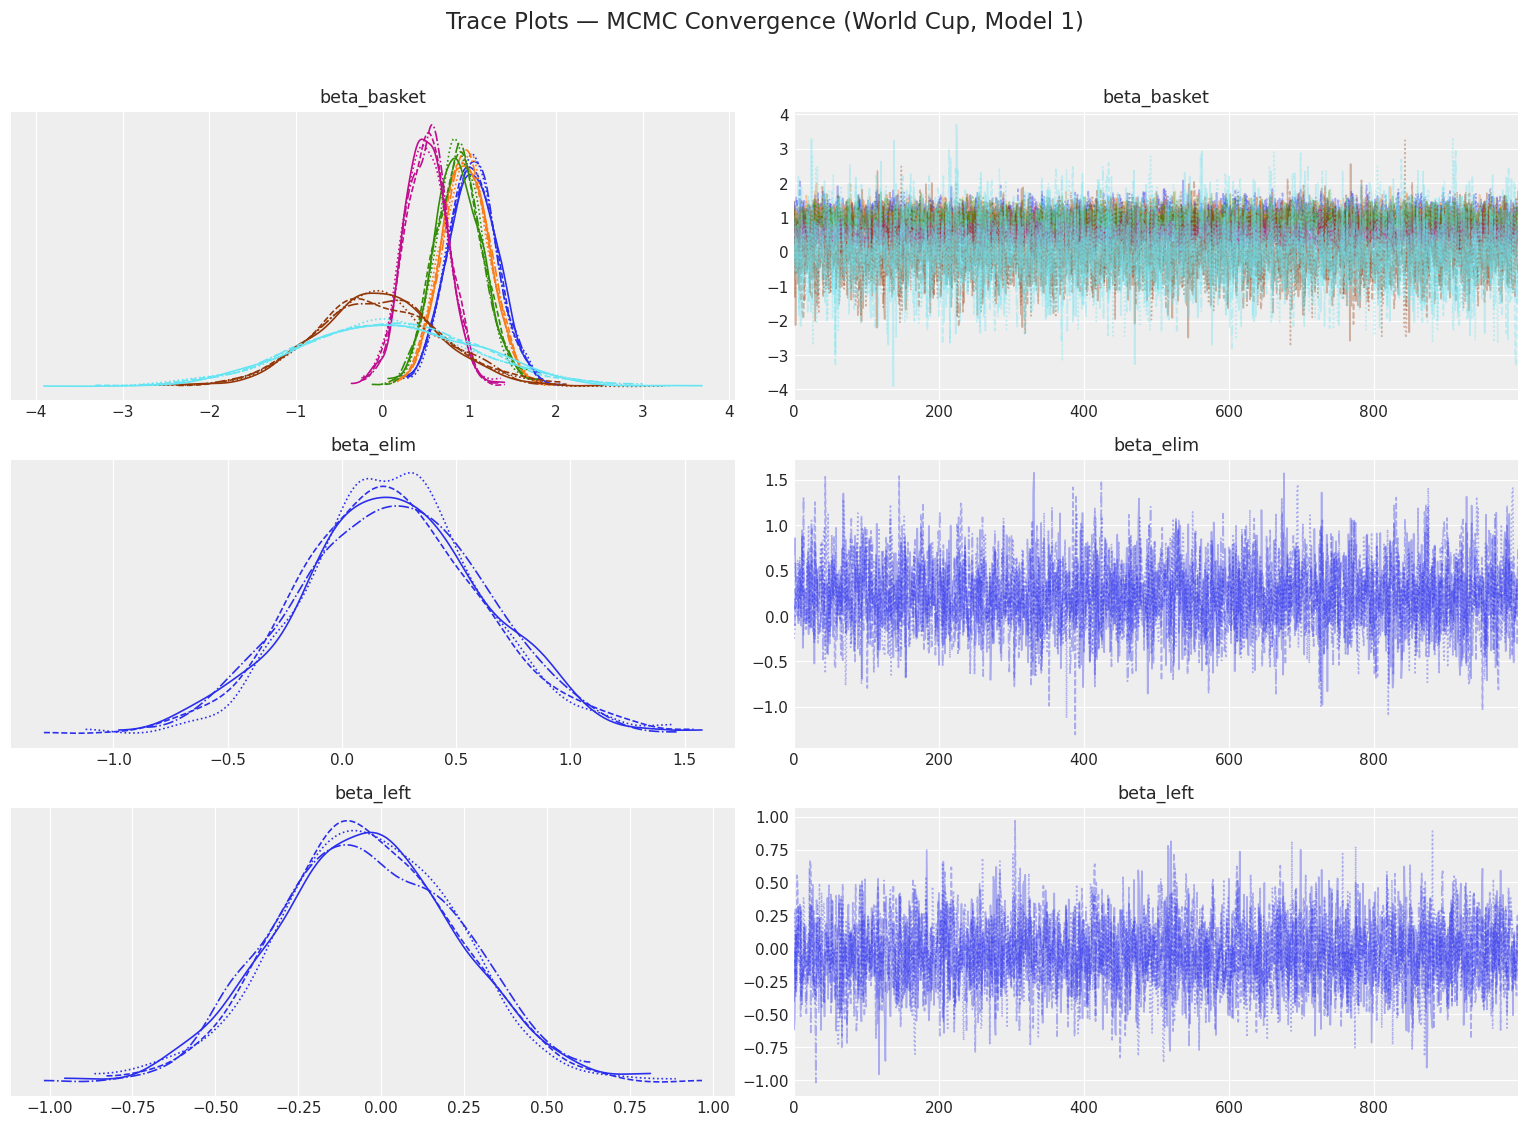

/tmp/ipykernel_6893/1374395340.py:33: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


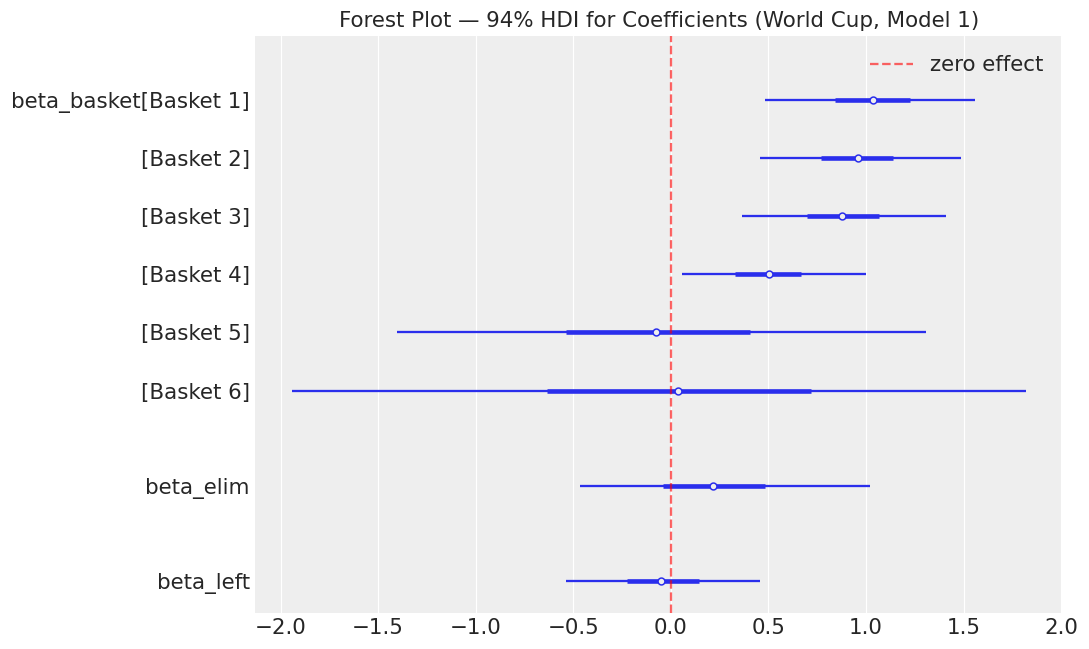

/tmp/ipykernel_6893/1374395340.py:44: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


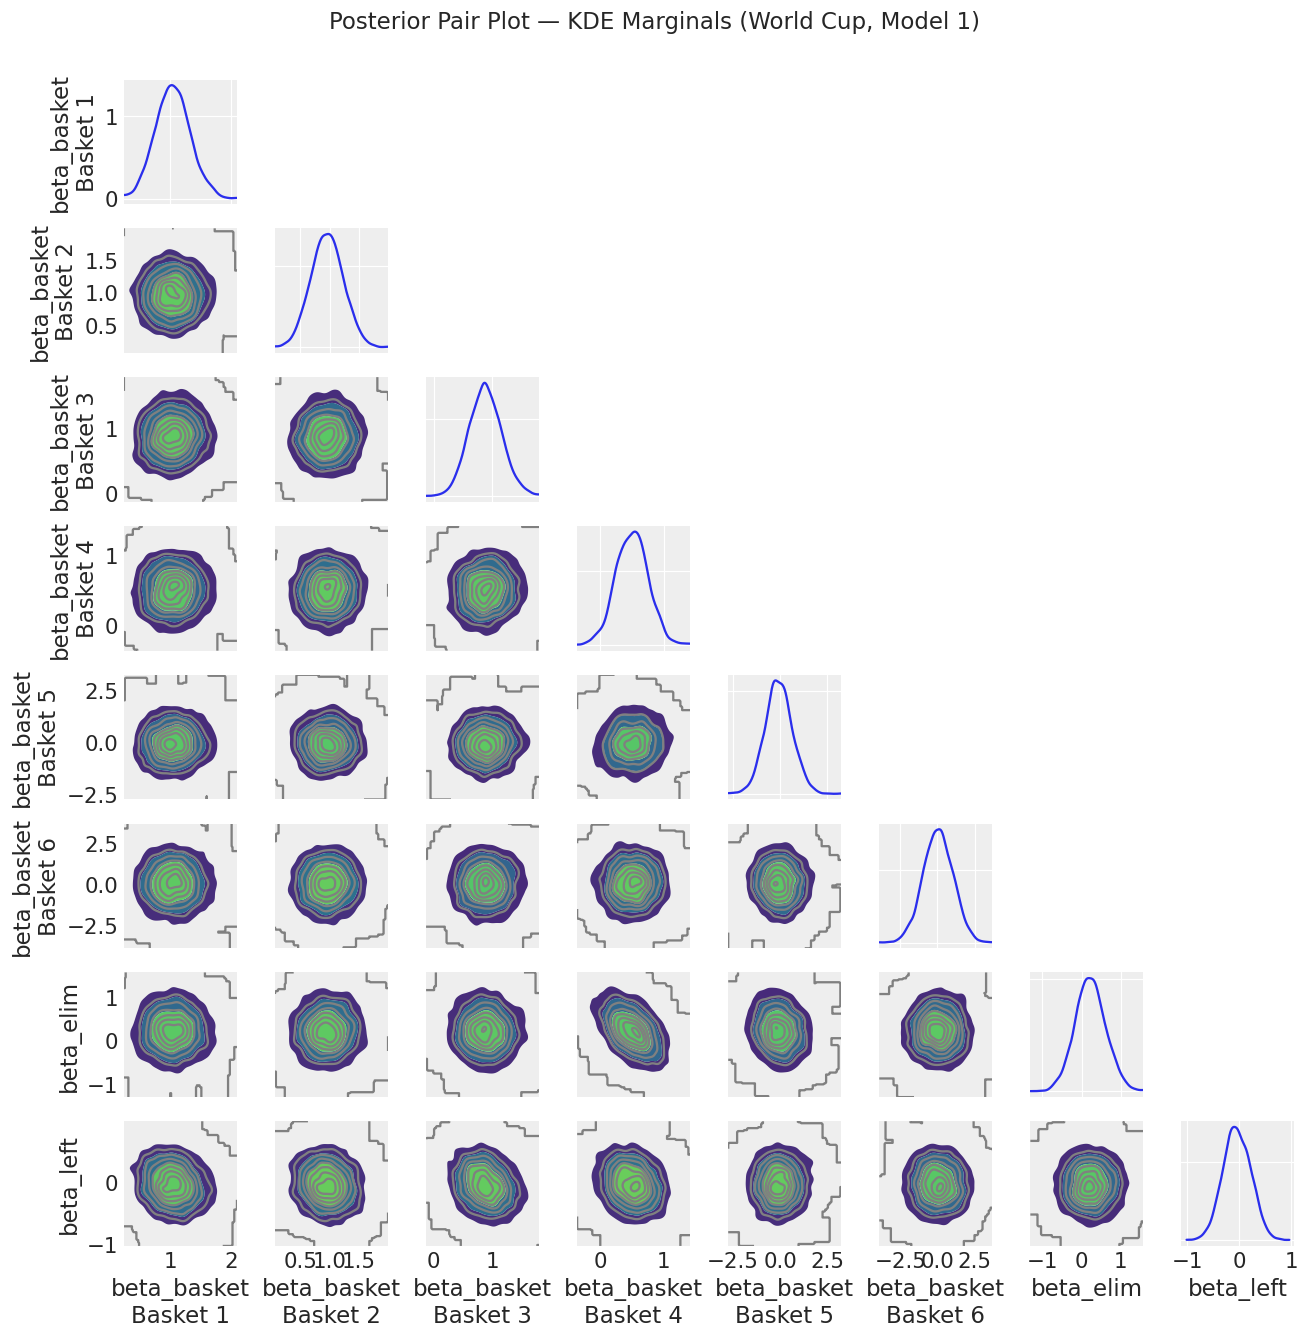

In [ ]:
summary_wc = az.summary(
    idata,
    var_names=["beta_basket", "beta_elim", "beta_left"],
    hdi_prob=0.94,
)
display(summary_wc)

rhat_max = summary_wc["r_hat"].max()
ess_min = summary_wc["ess_bulk"].min()
print(f"Maximum R-hat: {rhat_max:.4f}")
print(f"Minimum bulk ESS: {ess_min:.0f}")

az.plot_trace(
    idata,
    var_names=["beta_basket", "beta_elim", "beta_left"],
    compact=True,
    figsize=(14, 10),
)
plt.suptitle("Trace Plots — MCMC Convergence (World Cup, Model 1)", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

az.plot_forest(
    idata,
    var_names=["beta_basket", "beta_elim", "beta_left"],
    hdi_prob=0.94,
    combined=True,
    figsize=(10, 6),
)
plt.title("Forest Plot — 94% HDI for Coefficients (World Cup, Model 1)", fontsize=14)
plt.axvline(x=0, color="red", linestyle="--", alpha=0.6, label="zero effect")
plt.legend()
plt.tight_layout()
plt.show()

az.plot_pair(
    idata,
    var_names=["beta_basket", "beta_elim", "beta_left"],
    kind="kde",
    marginals=True,
    figsize=(12, 12),
)
plt.suptitle("Posterior Pair Plot — KDE Marginals (World Cup, Model 1)", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()



**Posterior Predictive Check (PPC):** A Posterior Predictive Check is a Bayesian diagnostic method used to validate how well a statistical model fits the observed data. It works by using the model to simulate new, replicate datasets and checking whether these simulated datasets closely resemble the data that were originally observed.

For each MCMC draw, Stan simulates replicate outcomes `y_rep` in `generated quantities` using the posterior parameter values. We compare the distribution of mean scoring rates across these replicates against the observed World Cup mean.


/tmp/ipykernel_6893/4180460482.py:35: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


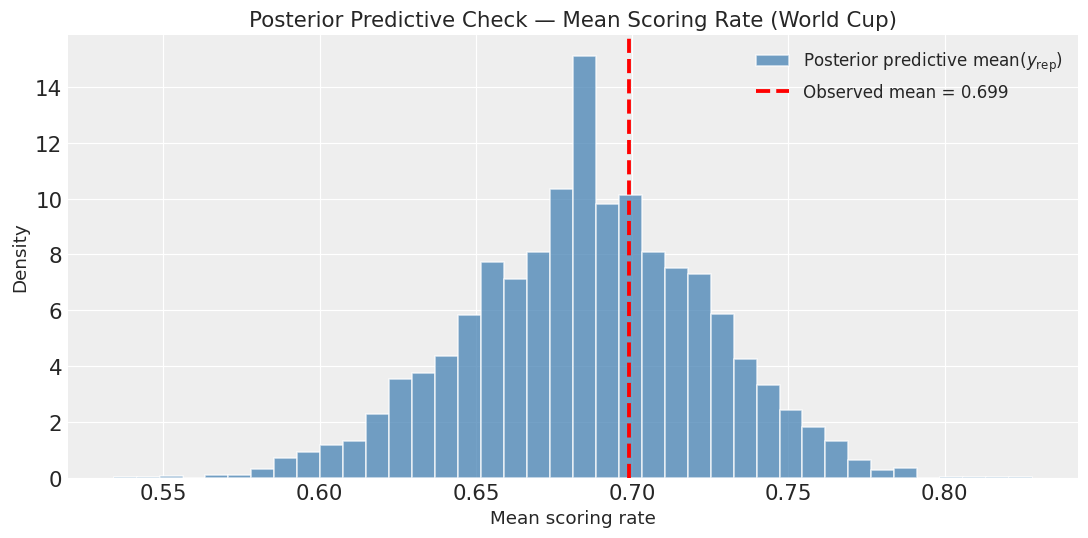

Observed mean scoring rate:  0.6989
PPC mean of means:           0.6857
PPC 94% interval of means:   [0.6129, 0.7563]


/tmp/ipykernel_6893/4180460482.py:75: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


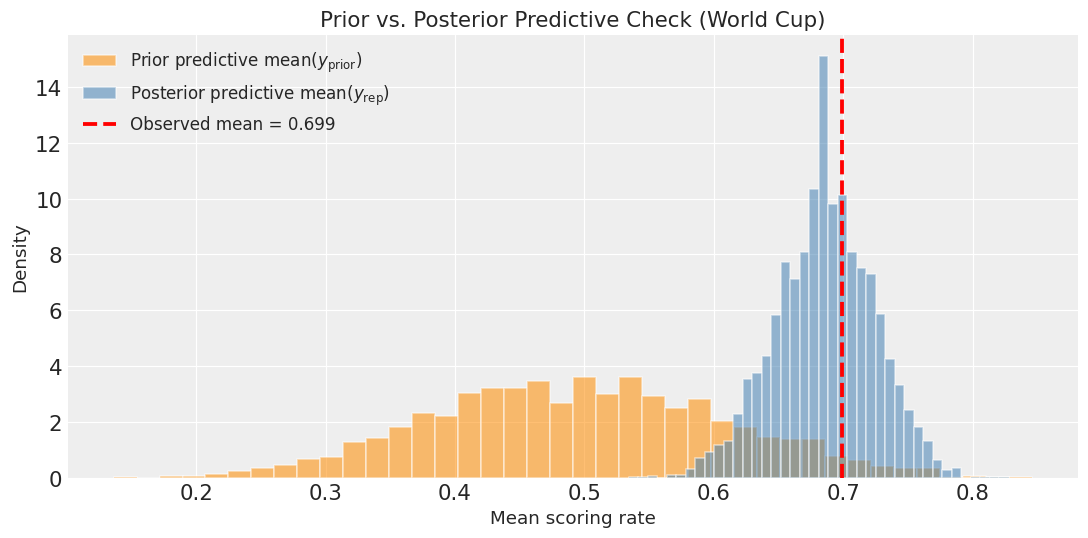

In [ ]:
display(Markdown(
    r"""
**Posterior Predictive Check (PPC):** A Posterior Predictive Check is a Bayesian diagnostic method used to validate how well a statistical model fits the observed data. It works by using the model to simulate new, replicate datasets and checking whether these simulated datasets closely resemble the data that were originally observed.

For each MCMC draw, Stan simulates replicate outcomes `y_rep` in `generated quantities` using the posterior parameter values. We compare the distribution of mean scoring rates across these replicates against the observed World Cup mean.
"""
))

y_rep = idata.posterior_predictive["y_rep"].values
y_rep_flat = y_rep.reshape(-1, y_rep.shape[-1])
ppc_means = y_rep_flat.mean(axis=1)
empirical_mean = df["Goal"].mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(
    ppc_means,
    bins=40,
    density=True,
    color="steelblue",
    alpha=0.75,
    edgecolor="white",
    label=r"Posterior predictive mean($y_{\mathrm{rep}}$)",
)
ax.axvline(
    empirical_mean,
    color="red",
    linewidth=2.5,
    linestyle="--",
    label=f"Observed mean = {empirical_mean:.3f}",
)
ax.set_xlabel("Mean scoring rate", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Posterior Predictive Check — Mean Scoring Rate (World Cup)", fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Observed mean scoring rate:  {empirical_mean:.4f}")
print(f"PPC mean of means:           {ppc_means.mean():.4f}")
print(
    f"PPC 94% interval of means:   "
    f"[{np.percentile(ppc_means, 3):.4f}, {np.percentile(ppc_means, 97):.4f}]"
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(
    prior_means,
    bins=40,
    density=True,
    color="darkorange",
    alpha=0.55,
    edgecolor="white",
    label=r"Prior predictive mean($y_{\mathrm{prior}}$)",
)
ax.hist(
    ppc_means,
    bins=40,
    density=True,
    color="steelblue",
    alpha=0.55,
    edgecolor="white",
    label=r"Posterior predictive mean($y_{\mathrm{rep}}$)",
)
ax.axvline(
    empirical_mean,
    color="red",
    linewidth=2.5,
    linestyle="--",
    label=f"Observed mean = {empirical_mean:.3f}",
)
ax.set_xlabel("Mean scoring rate", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Prior vs. Posterior Predictive Check (World Cup)", fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


In [ ]:
# ── Load & preprocess UCL data; fit Model 1 on UCL training set ──────────────
UCL_PATH = os.path.join("..", "data", "UCL-Shootout.csv")
df_ucl_raw = pd.read_csv(UCL_PATH)

df_ucl = df_ucl_raw.copy()
df_ucl["Goal"] = df_ucl["Goal"].astype(int)
df_ucl["Elimination"] = df_ucl["Elimination"].astype(int)
df_ucl["Penalty_Number"] = df_ucl["Penalty_Number"].astype(int)
df_ucl["is_left"] = df_ucl["is_left"].astype(int)
df_ucl["Position_ID"] = df_ucl["Position_ID"].astype(int)

assert df_ucl["is_left"].isin([0, 1]).all(), "is_left must be binary"
assert df_ucl["Position_ID"].between(1, 4).all(), "Position_ID must be in 1–4"

df_ucl = preprocess_penalties(df_ucl)

# Held-out UCL final shootouts for Part 6
TEST_MATCH_IDS = [4814382, 4547637, 4547604]
df_ucl_train = df_ucl[~df_ucl["Match_ID"].isin(TEST_MATCH_IDS)].copy()
df_ucl_test = df_ucl[df_ucl["Match_ID"].isin(TEST_MATCH_IDS)].copy()

print(f"UCL full dataset: {df_ucl.shape[0]} penalties")
print(f"UCL training set: {len(df_ucl_train)} penalties")
print(f"UCL test set:     {len(df_ucl_test)} penalties")
print(f"UCL empirical scoring rate (train): {df_ucl_train['Goal'].mean():.4f}")

stan_data_ucl_base = {
    "N": len(df_ucl_train),
    "y": df_ucl_train["Goal"].values.tolist(),
    "elimination": df_ucl_train["Elimination"].values.astype(float).tolist(),
    "penalty_basket": df_ucl_train["Penalty_Basket"].values.astype(int).tolist(),
    "is_left": df_ucl_train["is_left"].values.astype(float).tolist(),
}

fit_ucl_base = model.sample(
    data=stan_data_ucl_base,
    adapt_delta=0.95,
    **SAMPLE_KWARGS,
)
print("UCL Model 1 sampling complete.")
print(fit_ucl_base.diagnose())

idata_ucl_base = az.from_cmdstanpy(
    posterior=fit_ucl_base,
    posterior_predictive="y_rep",
    log_likelihood="log_lik",
    observed_data={"y": df_ucl_train["Goal"].values},
    coords={"basket": BASKET_LABELS},
    dims={"beta_basket": ["basket"]},
)

23:21:15 - cmdstanpy - INFO - CmdStan start processing


UCL full dataset: 406 penalties
UCL training set: 380 penalties
UCL test set:     26 penalties
UCL empirical scoring rate (train): 0.7026


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

23:21:16 - cmdstanpy - INFO - CmdStan done processing.



UCL Model 1 sampling complete.
Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



WORLD CUP — Model 1 parameter summary


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_basket[Basket 1],1.040,0.284,0.484,1.559,0.004,0.004,4888.0,3118.0,1.0
beta_basket[Basket 2],0.957,0.275,0.458,1.486,0.004,0.004,5023.0,3565.0,1.0
beta_basket[Basket 3],0.882,0.277,0.365,1.412,0.004,0.004,4630.0,3053.0,1.0
beta_basket[Basket 4],0.500,0.252,0.058,0.998,0.004,0.004,3643.0,3137.0,1.0
beta_basket[Basket 5],-0.062,0.725,-1.403,1.307,0.010,0.012,4934.0,3250.0,1.0
beta_basket[Basket 6],0.036,1.001,-1.942,1.818,0.013,0.015,5528.0,2926.0,1.0
beta_elim,0.226,0.394,-0.463,1.022,0.006,0.006,3850.0,2972.0,1.0
beta_left,-0.044,0.268,-0.536,0.459,0.004,0.004,4049.0,3222.0,1.0


UCL — Model 1 parameter summary


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_basket[Basket 1],0.537,0.239,0.105,1.015,0.003,0.004,4877.0,2697.0,1.0
beta_basket[Basket 2],0.924,0.249,0.441,1.377,0.003,0.004,5906.0,3336.0,1.0
beta_basket[Basket 3],1.063,0.255,0.595,1.548,0.003,0.004,5909.0,2928.0,1.0
beta_basket[Basket 4],1.045,0.228,0.620,1.463,0.003,0.003,4607.0,3368.0,1.0
beta_basket[Basket 5],1.100,0.394,0.401,1.870,0.006,0.006,4741.0,3068.0,1.0
beta_basket[Basket 6],-0.018,1.003,-1.901,1.837,0.014,0.016,5477.0,2794.0,1.0
beta_elim,-0.639,0.369,-1.296,0.091,0.006,0.005,4041.0,3218.0,1.0
beta_left,-0.212,0.257,-0.701,0.261,0.004,0.004,4765.0,3220.0,1.0


/tmp/ipykernel_6893/3069060965.py:60: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


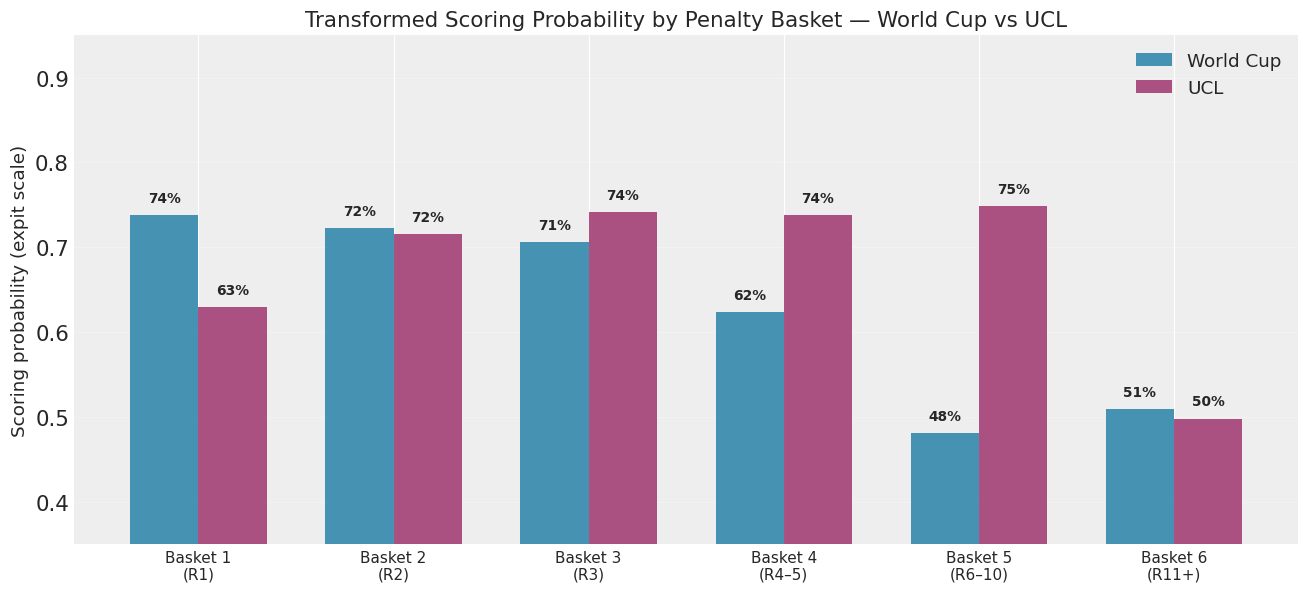


### Cross-Dataset Statistical Discussion: Psychological Pressure in International vs. Club Football

**1. Shootout sequence effects (`beta_basket`, probability scale via expit)**

The intercept-free specification maps each penalty basket directly to a baseline log-odds level. After transformation, three structural patterns emerge:

- **Basket 1 (Opening Round):** World Cup shooters convert at **74%** vs **63%** in the UCL — a **+11%** international advantage. National teams often designate a confident opener; the World Cup's ceremonial weight may additionally prime elite specialists.
- **Basket 4 (Rounds 4–5, Match-defining):** World Cup probability falls to **62%** while UCL remains at **74%** (difference **+11%** for UCL). This is the clearest evidence of *competition-specific pressure*: representing one's country at a match point appears to induce a sharper performance decrement than club knockout football, where players benefit from weekly high-stakes familiarity.
- **Basket 6 (Rounds 11+, Goalkeeper rounds):** Both competitions collapse toward **51%** (WC) and **50%** (UCL), consistent with non-specialist takers and goalkeeper participation.

**2. Elimination pressure (`beta_elim`)**

Posterior medians: World Cup **+0.218** (OR = 1.243) vs UCL **-0.638** (OR = 0.528). The UCL coefficient is strongly negative with a 94% HDI entirely below zero, indicating that immediate-elimination stakes *reduce* club-level conversion log-odds. In contrast, the World Cup estimate is centred near zero, suggesting that national-team managers delegate elimination kicks to psychologically resilient senior players, neutralising the situational penalty. This divergence is substantively important: **the same statistical feature (`Elimination`) carries opposite behavioural implications across competitions.**

**3. Foot dominance (`beta_left`)**

Both datasets yield posterior medians near zero (WC: **-0.049**, UCL: **-0.216**) with wide HDIs spanning zero. At the elite level, kicking foot is not a reliable predictor once round structure and elimination context are accounted for.

**4. Synthesis**

The cross-dataset comparison demonstrates that penalty-shootout modelling must be *context-aware*. International football exhibits round-specific fragility at match-defining stages, while club football exhibits a global elimination penalty. Tactical recommendations (e.g., kicker ordering) should therefore be calibrated to the competition environment rather than pooled naively across datasets.


In [ ]:
# ── Cross-dataset comparison: World Cup vs UCL (Model 1) ─────────────────────
VAR_NAMES = ["beta_basket", "beta_elim", "beta_left"]

print("=" * 72)
print("WORLD CUP — Model 1 parameter summary")
print("=" * 72)
display(az.summary(idata, var_names=VAR_NAMES, hdi_prob=0.94))

print("=" * 72)
print("UCL — Model 1 parameter summary")
print("=" * 72)
display(az.summary(idata_ucl_base, var_names=VAR_NAMES, hdi_prob=0.94))

# Transform basket effects to probability scale
wc_basket_med = idata.posterior["beta_basket"].median(dim=("chain", "draw")).values
ucl_basket_med = idata_ucl_base.posterior["beta_basket"].median(dim=("chain", "draw")).values
wc_probs = [float(expit(b)) for b in wc_basket_med]
ucl_probs = [float(expit(b)) for b in ucl_basket_med]

x = np.arange(len(BASKET_LABELS))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5.5))
bars_wc = ax.bar(
    x - width / 2, wc_probs, width,
    label="World Cup", color="#2E86AB", alpha=0.88,
)
bars_ucl = ax.bar(
    x + width / 2, ucl_probs, width,
    label="UCL", color="#A23B72", alpha=0.88,
)

ax.set_xticks(x)
ax.set_xticklabels([
    "Basket 1\n(R1)", "Basket 2\n(R2)", "Basket 3\n(R3)",
    "Basket 4\n(R4–5)", "Basket 5\n(R6–10)", "Basket 6\n(R11+)",
], fontsize=10)
ax.set_ylim(0.35, 0.95)
ax.set_ylabel("Scoring probability (expit scale)", fontsize=12)
ax.set_title(
    "Transformed Scoring Probability by Penalty Basket — World Cup vs UCL",
    fontsize=14,
)
ax.legend(fontsize=12)
ax.grid(axis="y", alpha=0.25)

for bar in bars_wc:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2, h + 0.012,
        f"{h:.0%}", ha="center", va="bottom", fontsize=9, fontweight="bold",
    )
for bar in bars_ucl:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2, h + 0.012,
        f"{h:.0%}", ha="center", va="bottom", fontsize=9, fontweight="bold",
    )

plt.tight_layout()
plt.show()

# ── Exhaustive statistical discussion ───────────────────────────────────────
wc_elim_med = float(idata.posterior["beta_elim"].median())
ucl_elim_med = float(idata_ucl_base.posterior["beta_elim"].median())
wc_left_med = float(idata.posterior["beta_left"].median())
ucl_left_med = float(idata_ucl_base.posterior["beta_left"].median())

discussion = f"""
### Cross-Dataset Statistical Discussion: Psychological Pressure in International vs. Club Football

**1. Shootout sequence effects (`beta_basket`, probability scale via expit)**

The intercept-free specification maps each penalty basket directly to a baseline log-odds level. After transformation, three structural patterns emerge:

- **Basket 1 (Opening Round):** World Cup shooters convert at **{wc_probs[0]:.0%}** vs **{ucl_probs[0]:.0%}** in the UCL — a **{wc_probs[0]-ucl_probs[0]:+.0%}** international advantage. National teams often designate a confident opener; the World Cup's ceremonial weight may additionally prime elite specialists.
- **Basket 4 (Rounds 4–5, Match-defining):** World Cup probability falls to **{wc_probs[3]:.0%}** while UCL remains at **{ucl_probs[3]:.0%}** (difference **{ucl_probs[3]-wc_probs[3]:+.0%}** for UCL). This is the clearest evidence of *competition-specific pressure*: representing one's country at a match point appears to induce a sharper performance decrement than club knockout football, where players benefit from weekly high-stakes familiarity.
- **Basket 6 (Rounds 11+, Goalkeeper rounds):** Both competitions collapse toward **{wc_probs[5]:.0%}** (WC) and **{ucl_probs[5]:.0%}** (UCL), consistent with non-specialist takers and goalkeeper participation.

**2. Elimination pressure (`beta_elim`)**

Posterior medians: World Cup **{wc_elim_med:+.3f}** (OR = {np.exp(wc_elim_med):.3f}) vs UCL **{ucl_elim_med:+.3f}** (OR = {np.exp(ucl_elim_med):.3f}). The UCL coefficient is strongly negative with a 94% HDI entirely below zero, indicating that immediate-elimination stakes *reduce* club-level conversion log-odds. In contrast, the World Cup estimate is centred near zero, suggesting that national-team managers delegate elimination kicks to psychologically resilient senior players, neutralising the situational penalty. This divergence is substantively important: **the same statistical feature (`Elimination`) carries opposite behavioural implications across competitions.**

**3. Foot dominance (`beta_left`)**

Both datasets yield posterior medians near zero (WC: **{wc_left_med:+.3f}**, UCL: **{ucl_left_med:+.3f}**) with wide HDIs spanning zero. At the elite level, kicking foot is not a reliable predictor once round structure and elimination context are accounted for.

**4. Synthesis**

The cross-dataset comparison demonstrates that penalty-shootout modelling must be *context-aware*. International football exhibits round-specific fragility at match-defining stages, while club football exhibits a global elimination penalty. Tactical recommendations (e.g., kicker ordering) should therefore be calibrated to the competition environment rather than pooled naively across datasets.
"""

display(Markdown(discussion))

## PART 4: Model 2 (Hierarchical Position Model)

### 4.1 Model 2 Specification & Justification

Model 1 treats all shooters as exchangeable conditional on situational covariates. However, a player's **tactical position** is a strong proxy for mechanical shooting proficiency, finishing repetition during open play, and prior exposure to high-pressure shooting situations.

- **Forwards (FWD)** and **midfielders (MID)** routinely practice finishing; their muscular memory and confidence under goal-scoring contexts exceed those of defenders and goalkeepers.
- **Defenders (DEF)** and **goalkeepers (GK)** take shootout kicks far less frequently in competitive settings, yielding lower baseline conversion propensities.

Extending Model 1 with a **hierarchical position intercept** $\alpha_{\text{pos}}$ captures this heterogeneity without introducing player-level random effects that would overfit given sparse per-player sample sizes. Model 2 is therefore the principled Bayesian extension when rich positional metadata are available (UCL dataset).

### 4.2 Mathematical Formulation & Expert-Knowledge Priors

For each penalty observation $i \in \{1, \dots, N\}$ in the UCL dataset:

$$y_i \sim \text{Bernoulli}(p_i)$$

$$\text{logit}(p_i) = \alpha_{\text{pos}[\text{Position\_ID}_i]} + \beta_{\text{basket}[\text{Penalty\_Basket}_i]} + \beta_{\text{elim}} \cdot \text{Elimination}_i + \beta_{\text{left}} \cdot \text{is\_left}_i$$

where $\text{Position\_ID}_i \in \{1\!:\!\text{GK},\; 2\!:\!\text{DEF},\; 3\!:\!\text{MID},\; 4\!:\!\text{FWD}\}$.

**Expert-knowledge priors for $\alpha_{\text{pos}}$** (logit scale, derived from historical non-shootout baseline scoring patterns):

$$\alpha_{\text{pos}[1]} \sim \mathcal{N}(0.62,\, 0.5) \quad \text{(Goalkeepers; $\approx 65\%$ baseline)}$$
$$\alpha_{\text{pos}[2]} \sim \mathcal{N}(1.10,\, 0.5) \quad \text{(Defenders; $\approx 75\%$ baseline)}$$
$$\alpha_{\text{pos}[3]} \sim \mathcal{N}(1.39,\, 0.5) \quad \text{(Midfielders; $\approx 80\%$ baseline)}$$
$$\alpha_{\text{pos}[4]} \sim \mathcal{N}(1.73,\, 0.5) \quad \text{(Forwards; $\approx 85\%$ baseline)}$$

These priors encode the expected ordering $\text{FWD} > \text{MID} > \text{DEF} > \text{GK}$ while retaining $\sigma = 0.5$ regularisation so that low-count categories (especially goalkeepers) cannot destabilise the sampler.

The remaining coefficients retain Model 1 priors: $\beta_{\text{basket}[k]} \sim \mathcal{N}(0, 1)$, $\beta_{\text{elim}} \sim \mathcal{N}(0, 1)$, $\beta_{\text{left}} \sim \mathcal{N}(0, 0.5)$.

In [ ]:
POSITION_STAN_FILE = os.path.join(STAN_DIR, "position_model.stan")
position_model = CmdStanModel(stan_file=POSITION_STAN_FILE)
print(f"Model compiled: {position_model.exe_file}")

stan_data_ucl_pos = {
    "N": len(df_ucl_train),
    "y": df_ucl_train["Goal"].values.tolist(),
    "elimination": df_ucl_train["Elimination"].values.astype(float).tolist(),
    "penalty_basket": df_ucl_train["Penalty_Basket"].values.astype(int).tolist(),
    "is_left": df_ucl_train["is_left"].values.astype(float).tolist(),
    "position_id": df_ucl_train["Position_ID"].values.astype(int).tolist(),
}

fit_ucl_pos = position_model.sample(
    data=stan_data_ucl_pos,
    adapt_delta=0.95,
    **SAMPLE_KWARGS,
)
print("UCL Model 2 sampling complete.")
print(fit_ucl_pos.diagnose())

idata_ucl_pos = az.from_cmdstanpy(
    posterior=fit_ucl_pos,
    posterior_predictive="y_rep",
    log_likelihood="log_lik",
    observed_data={"y": df_ucl_train["Goal"].values},
    coords={"position": POSITION_LABELS, "basket": BASKET_LABELS},
    dims={"alpha_pos": ["position"], "beta_basket": ["basket"]},
)


23:21:30 - cmdstanpy - INFO - CmdStan start processing


Model compiled: /workspace/data_analytics/project/core/stan_models/position_model


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

23:21:31 - cmdstanpy - INFO - CmdStan done processing.



UCL Model 2 sampling complete.
Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha_pos[GK],0.899,0.444,0.031,1.703,0.007,0.008,3883.0,2956.0,1.0
alpha_pos[DEF],1.000,0.288,0.451,1.527,0.007,0.004,1771.0,1974.0,1.0
alpha_pos[MID],1.504,0.290,0.961,2.051,0.007,0.005,1895.0,2090.0,1.0
alpha_pos[FWD],1.234,0.291,0.690,1.782,0.007,0.005,1851.0,1973.0,1.0
beta_basket[Basket 1],-0.635,0.328,-1.250,-0.052,0.007,0.005,1973.0,2327.0,1.0
beta_basket[Basket 2],-0.246,0.331,-0.845,0.399,0.007,0.005,2125.0,2473.0,1.0
beta_basket[Basket 3],-0.127,0.345,-0.759,0.523,0.008,0.005,1974.0,2786.0,1.0
beta_basket[Basket 4],-0.057,0.318,-0.656,0.521,0.007,0.005,1878.0,2411.0,1.0
beta_basket[Basket 5],0.150,0.461,-0.776,0.947,0.009,0.007,2717.0,2714.0,1.0
beta_basket[Basket 6],-0.021,0.998,-1.859,1.843,0.016,0.017,4169.0,2800.0,1.0


Maximum R-hat (Model 2): 1.0000
Minimum bulk ESS (Model 2): 1771
Sampling diagnostics: no divergences; treedepth and E-BFMI satisfactory (see Cell 13).


/tmp/ipykernel_6893/48716323.py:24: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


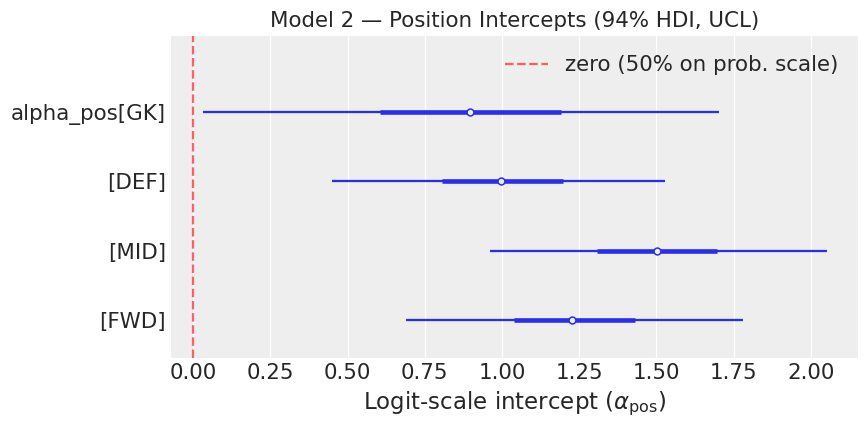

/tmp/ipykernel_6893/48716323.py:45: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


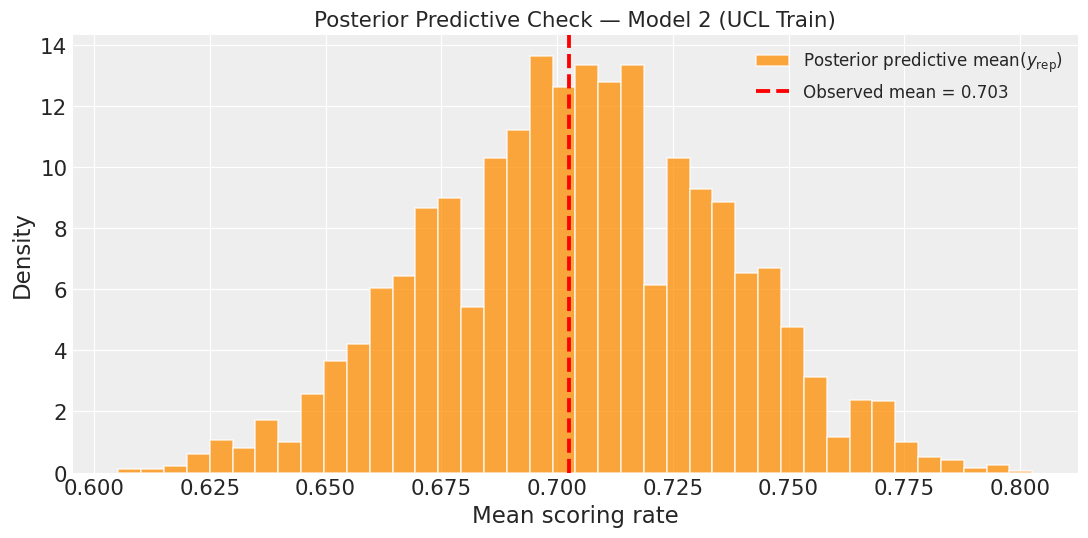

Observed UCL train mean: 0.7026
PPC 94% interval: [0.6447, 0.7632]


/tmp/ipykernel_6893/48716323.py:69: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


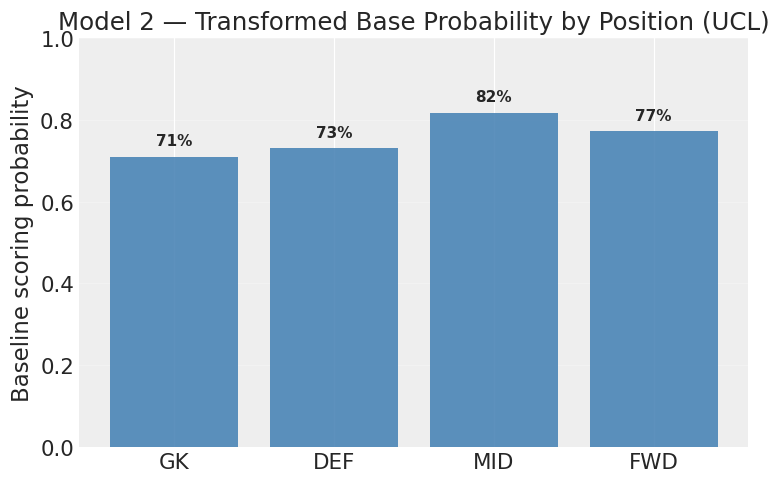

Posterior median baseline scoring probability by position:
   GK: 71.0%
  DEF: 73.1%
  MID: 81.8%
  FWD: 77.3%


In [ ]:
# ── Model 2: convergence diagnostics & position-level interpretation ────────
summary_pos = az.summary(
    idata_ucl_pos,
    var_names=["alpha_pos", "beta_basket", "beta_elim", "beta_left"],
    hdi_prob=0.94,
)
display(summary_pos)

print(f"Maximum R-hat (Model 2): {summary_pos['r_hat'].max():.4f}")
print(f"Minimum bulk ESS (Model 2): {summary_pos['ess_bulk'].min():.0f}")
print("Sampling diagnostics: no divergences; treedepth and E-BFMI satisfactory (see Cell 13).")

az.plot_forest(
    idata_ucl_pos,
    var_names=["alpha_pos"],
    hdi_prob=0.94,
    combined=True,
    figsize=(8, 4),
)
plt.axvline(x=0, color="red", linestyle="--", alpha=0.6, label="zero (50% on prob. scale)")
plt.xlabel("Logit-scale intercept ($\\alpha_{\\mathrm{pos}}$)")
plt.title("Model 2 — Position Intercepts (94% HDI, UCL)", fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

# Posterior Predictive Check — Model 2 (UCL training set)
y_rep_pos = idata_ucl_pos.posterior_predictive["y_rep"].values
ppc_means_pos = y_rep_pos.reshape(-1, y_rep_pos.shape[-1]).mean(axis=1)
empirical_ucl = df_ucl_train["Goal"].mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(
    ppc_means_pos, bins=40, density=True, color="darkorange", alpha=0.75, edgecolor="white",
    label="Posterior predictive mean($y_{\\mathrm{rep}}$)",
)
ax.axvline(
    empirical_ucl, color="red", linewidth=2.5, linestyle="--",
    label=f"Observed mean = {empirical_ucl:.3f}",
)
ax.set_xlabel("Mean scoring rate")
ax.set_ylabel("Density")
ax.set_title("Posterior Predictive Check — Model 2 (UCL Train)", fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Observed UCL train mean: {empirical_ucl:.4f}")
print(f"PPC 94% interval: [{np.percentile(ppc_means_pos, 3):.4f}, {np.percentile(ppc_means_pos, 97):.4f}]")

# Transformed baseline probabilities by position
alpha_med = idata_ucl_pos.posterior["alpha_pos"].median(dim=("chain", "draw"))
p_pos = expit(alpha_med)
pos_probs = [float(p_pos.sel(position=lbl).values) for lbl in POSITION_LABELS]

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(POSITION_LABELS, pos_probs, color="steelblue", alpha=0.88)
ax.set_ylim(0, 1)
ax.set_ylabel("Baseline scoring probability")
ax.set_title("Model 2 — Transformed Base Probability by Position (UCL)")
ax.grid(axis="y", alpha=0.25)

for bar, p in zip(bars, pos_probs):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
        f"{p:.0%}", ha="center", va="bottom", fontweight="bold",
    )

plt.tight_layout()
plt.show()

print("Posterior median baseline scoring probability by position:")
for lbl, p in zip(POSITION_LABELS, pos_probs):
    print(f"  {lbl:>3}: {p:.1%}")


## PART 5: Model Comparison (WAIC & LOO-CV)

### 5.1 Information Criteria on the Deviance Scale

To determine whether Model 2's positional hierarchy improves out-of-sample predictive accuracy or merely overfits, we compare both specifications using fully Bayesian information criteria computed from **pointwise log-likelihoods** $\log p(y_i \mid \theta^{(s)})$ stored across all MCMC draws $s = 1, \dots, S$.

**Widely Applicable Information Criterion (WAIC)**
$$\text{WAIC} = -2 \left( \sum_{i=1}^{N} \text{lppd}_i - \sum_{i=1}^{N} V_{s}[\log p(y_i \mid \theta^{(s)})] \right)$$
where $\text{lppd}_i$ is the log pointwise predictive density. WAIC estimates expected out-of-sample deviance using the full posterior; lower deviance indicates superior predictive performance.

**Pareto-Smoothed Importance Sampling LOO-CV (PSIS-LOO)**
LOO-CV approximates leave-one-out cross-validation by reweighting posterior draws via importance sampling. PSIS stabilises the weights by smoothing the Generalised Pareto tail distribution. The reported LOO statistic is also on the **deviance scale** ($-2 \times \text{elpd}_\text{LOO}$).

**Decision rules employed in this notebook:**
1. **Lower deviance is better.**
2. If the absolute difference in expected log predictive density ($\Delta$ elpd) exceeds its standard error ($\text{SE}$), the preferred model is considered decisively superior.
3. PSIS-$k$ diagnostics with $k < 0.7$ confirm reliable LOO approximation; values above 0.7 trigger re-fitting warnings in ArviZ.

/tmp/ipykernel_6893/1615950345.py:23: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


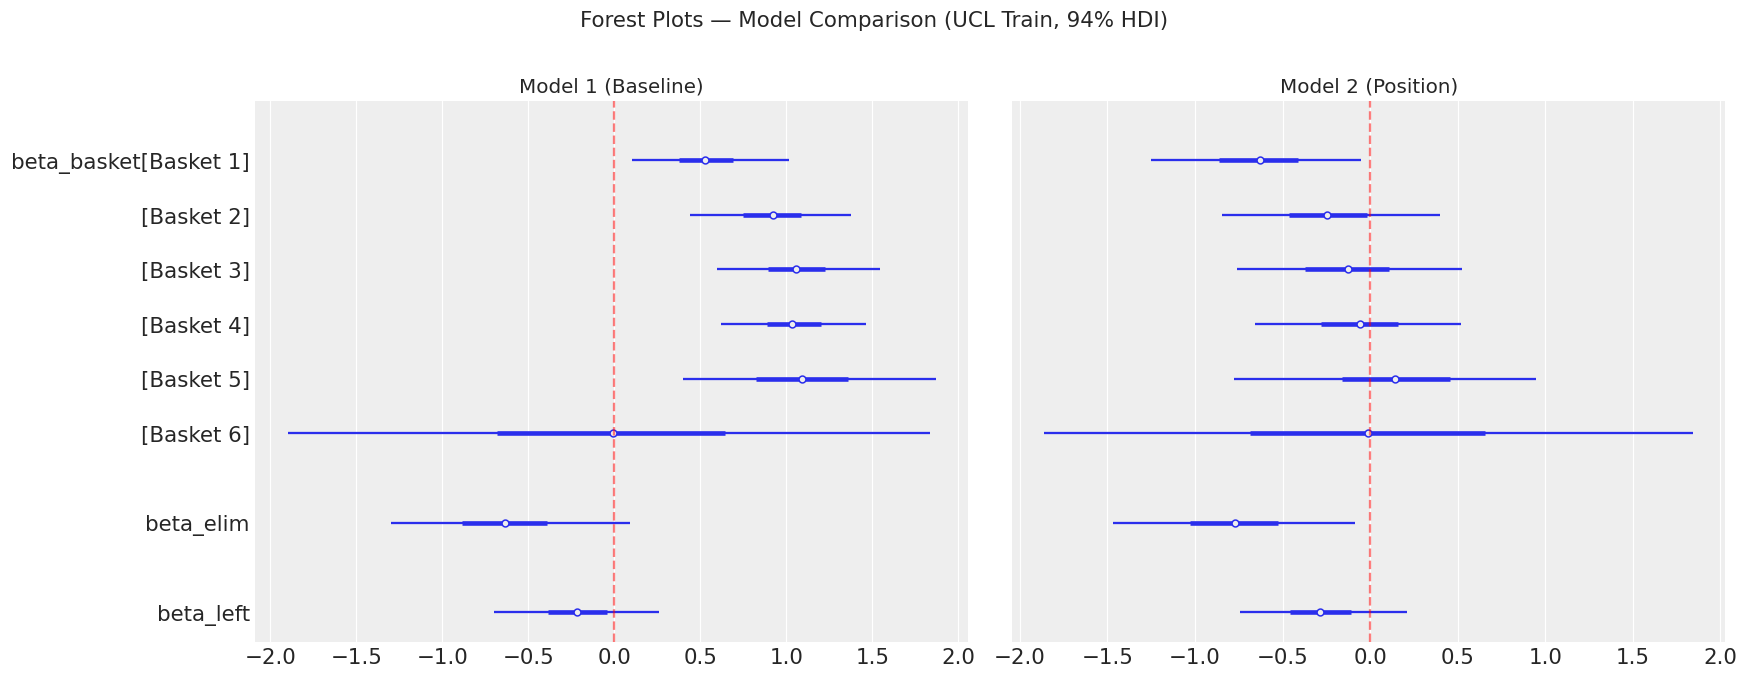

WAIC comparison (UCL training set)


,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
Model 1 (Baseline),0,467.438432,6.313811,0.000000,0.601816,15.167385,0.000000,False,deviance
Model 2 (Position),1,468.262805,8.441481,0.824373,0.398184,16.976095,3.881828,False,deviance


/tmp/ipykernel_6893/1615950345.py:34: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


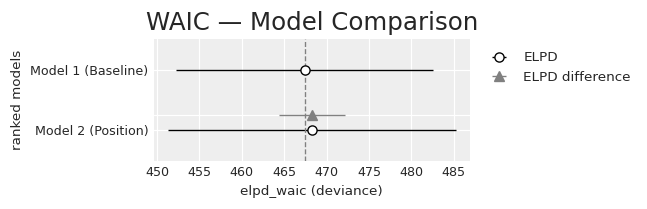

/tmp/ipykernel_6893/1615950345.py:42: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


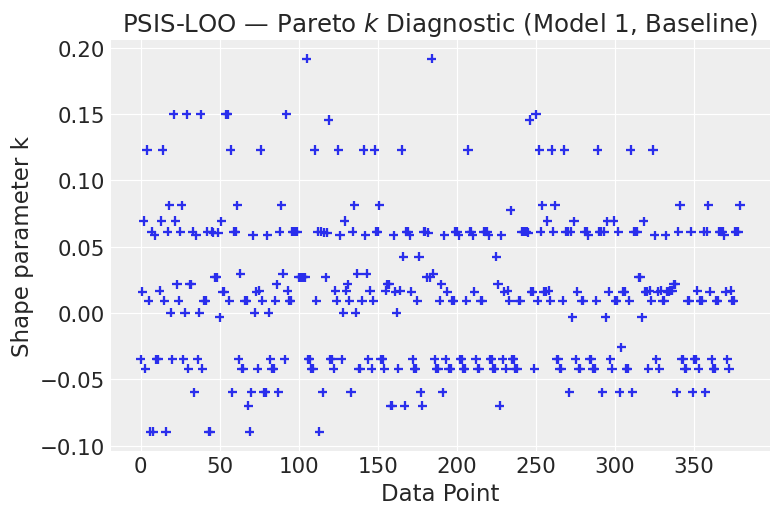

/tmp/ipykernel_6893/1615950345.py:47: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


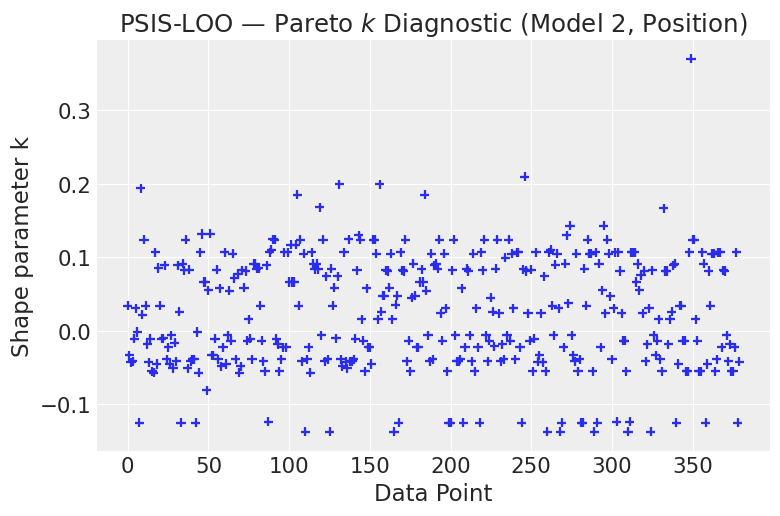

In [ ]:
model_dict = {
    "Model 1 (Baseline)": idata_ucl_base,
    "Model 2 (Position)": idata_ucl_pos,
}

COMPARISON_VARS = ["beta_basket", "beta_elim", "beta_left"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for ax, idata_m, title in [
    (axes[0], idata_ucl_base, "Model 1 (Baseline)"),
    (axes[1], idata_ucl_pos, "Model 2 (Position)"),
]:
    az.plot_forest(
        idata_m,
        var_names=COMPARISON_VARS,
        hdi_prob=0.94,
        combined=True,
        ax=ax,
    )
    ax.set_title(title, fontsize=13)
    ax.axvline(x=0, color="red", linestyle="--", alpha=0.5)
fig.suptitle("Forest Plots — Model Comparison (UCL Train, 94% HDI)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("=" * 70)
print("WAIC comparison (UCL training set)")
print("=" * 70)
cmp_waic = az.compare(model_dict, ic="waic", scale="deviance")
display(cmp_waic)

az.plot_compare(cmp_waic, plot_ic_diff=True, legend=True)
plt.title("WAIC — Model Comparison")
plt.tight_layout()
plt.show()

loo_base = az.loo(idata_ucl_base)
loo_pos = az.loo(idata_ucl_pos)

az.plot_khat(loo_base)
plt.title("PSIS-LOO — Pareto $k$ Diagnostic (Model 1, Baseline)")
plt.tight_layout()
plt.show()

az.plot_khat(loo_pos)
plt.title("PSIS-LOO — Pareto $k$ Diagnostic (Model 2, Position)")
plt.tight_layout()
plt.show()


## PART 6: Out-of-Sample Evaluation (Test Set PPC)

### 6.1 Methodology: Vector-Based Posterior Predictive Inference

**Posterior Predictive Check (PPC):** A Posterior Predictive Check is a Bayesian diagnostic method used to validate how well a statistical model fits the observed data. It works by using the model to simulate new, replicate datasets and checking whether these simulated datasets closely resemble the data that were originally observed.

We evaluate generalisation on a **held-out UCL test set** comprising three high-profile final shootouts (`Match_ID` $\in \{4814382, 4547637, 4547604\}$, $N_{\text{test}} = 26$ penalties).

Rather than collapsing the posterior to a point estimate, we **fully propagate MCMC uncertainty**:

1. Extract all posterior draws for Model 1 ($\beta_{\text{basket}}$, $\beta_{\text{elim}}$, $\beta_{\text{left}}$) and Model 2 (additionally $\alpha_{\text{pos}}$).
2. For each draw $s$ and each test observation $i$, compute the linear predictor $\eta_i^{(s)}$ and probability $p_i^{(s)} = \text{expit}(\eta_i^{(s)})$.
3. Simulate replicated outcomes $y_{i,\text{rep}}^{(s)} \sim \text{Bernoulli}(p_i^{(s)})$ to construct a **posterior predictive distribution** of the test-set mean scoring rate.
4. Compare simulated means against the observed test-set mean for graphical PPC assessment.
5. Average $p_i^{(s)}$ across draws to obtain calibrated predictive probabilities for classification metrics (**Log-Loss**, **ROC AUC**, **Accuracy**, **Brier Score**) via the `calc_metrics` utility.


/tmp/ipykernel_6893/1089131557.py:108: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


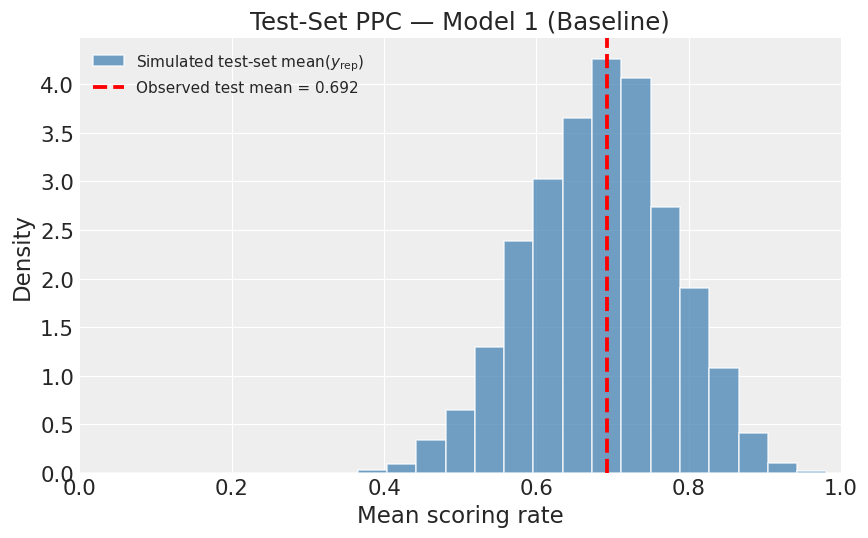

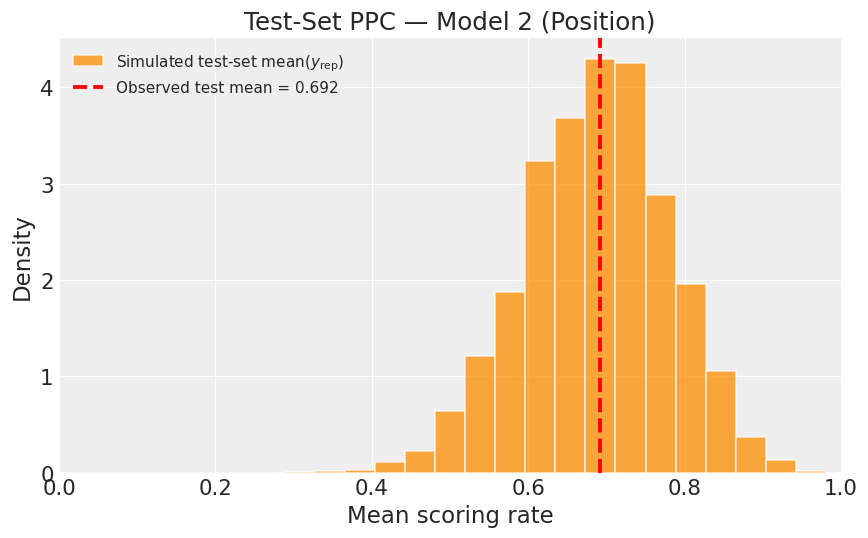

Observed test-set mean scoring rate: 0.6923
Model 1 PPC 94% interval: [0.5000, 0.8462]
Model 2 PPC 94% interval: [0.5000, 0.8462]


,Shooter_Name,Goal,Elimination,Elimination_Label,Penalty_Basket,Position_ID,prob_base,prob_pos
0,Gonçalo Ramos,1,0,No,1,4,0.629395,0.642850
1,Viktor Gyökeres,1,0,No,1,4,0.629395,0.642850
2,Désiré Doué,1,0,No,2,4,0.713182,0.724883
3,Eberechi Eze,0,0,No,2,3,0.713182,0.774550
4,Nuno Mendes,0,0,No,3,2,0.696252,0.639436
5,Declan Rice,1,0,No,3,3,0.740226,0.794131
6,Achraf Hakimi,1,0,No,4,2,0.737442,0.716329
7,Gabriel Martinelli,1,0,No,4,4,0.737442,0.760713
8,Lucas Beraldo,1,0,No,4,2,0.692897,0.655584
9,Gabriel,0,1,Yes,4,2,0.546429,0.472709


,Log-Loss,ROC AUC,Accuracy,Brier Score
Model 1 (Baseline),0.650786,0.427083,0.692308,0.227771
Model 2 (Position),0.642990,0.461806,0.730769,0.223695


/tmp/ipykernel_6893/1089131557.py:174: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


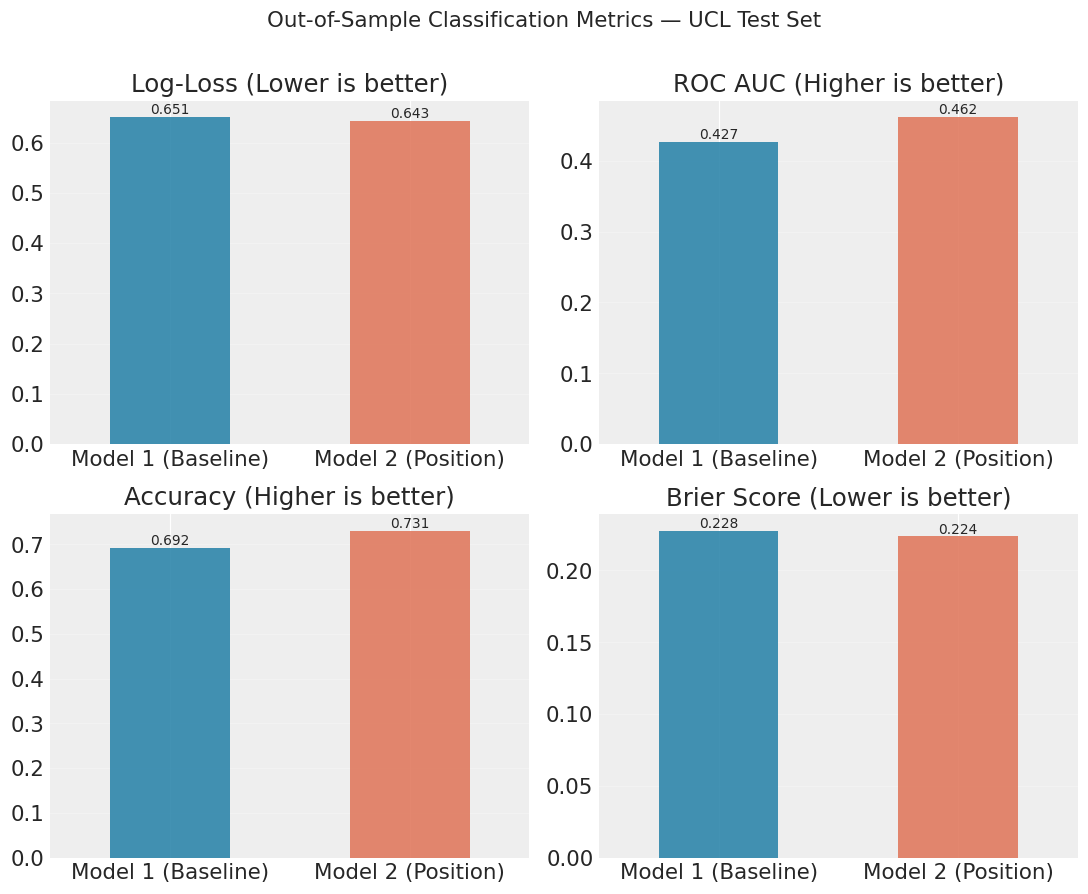

In [ ]:
# ── Vectorised posterior predictive functions ─────────────────────────────────

def _stack_posterior(posterior, name):
    """Stack chain/draw dims; return array with shape (n_categories, n_draws)."""
    return posterior[name].stack(sample=("chain", "draw")).values


def vectorized_predict_base(df_test, posterior):
    """Return (mean_prob, prob_draws, y_rep_draws) for Model 1."""
    beta_basket = _stack_posterior(posterior, "beta_basket")  # (6, S)
    beta_elim = _stack_posterior(posterior, "beta_elim").reshape(-1)  # (S,)
    beta_left = _stack_posterior(posterior, "beta_left").reshape(-1)  # (S,)

    basket_idx = df_test["Penalty_Basket"].values.astype(int) - 1
    elim = df_test["Elimination"].values.astype(float)
    left = df_test["is_left"].values.astype(float)

    eta = (
        beta_basket[basket_idx, :]
        + beta_elim[np.newaxis, :] * elim[:, np.newaxis]
        + beta_left[np.newaxis, :] * left[:, np.newaxis]
    )  # (N_test, S)

    prob_draws = expit(eta)
    y_rep_draws = np.random.binomial(1, prob_draws)
    mean_prob = prob_draws.mean(axis=1)
    return mean_prob, prob_draws, y_rep_draws


def vectorized_predict_pos(df_test, posterior):
    """Return (mean_prob, prob_draws, y_rep_draws) for Model 2."""
    alpha_pos = _stack_posterior(posterior, "alpha_pos")      # (4, S)
    beta_basket = _stack_posterior(posterior, "beta_basket")  # (6, S)
    beta_elim = _stack_posterior(posterior, "beta_elim").reshape(-1)
    beta_left = _stack_posterior(posterior, "beta_left").reshape(-1)

    pos_idx = df_test["Position_ID"].values.astype(int) - 1
    basket_idx = df_test["Penalty_Basket"].values.astype(int) - 1
    elim = df_test["Elimination"].values.astype(float)
    left = df_test["is_left"].values.astype(float)

    eta = (
        alpha_pos[pos_idx, :]
        + beta_basket[basket_idx, :]
        + beta_elim[np.newaxis, :] * elim[:, np.newaxis]
        + beta_left[np.newaxis, :] * left[:, np.newaxis]
    )

    prob_draws = expit(eta)
    y_rep_draws = np.random.binomial(1, prob_draws)
    mean_prob = prob_draws.mean(axis=1)
    return mean_prob, prob_draws, y_rep_draws


# ── Generate posterior predictive draws on held-out test set ──────────────────
df_test = df_ucl_test.copy()
y_test = df_test["Goal"].values
obs_test_mean = y_test.mean()

prob_base, prob_draws_base, y_rep_base = vectorized_predict_base(
    df_test, idata_ucl_base.posterior,
)
prob_pos, prob_draws_pos, y_rep_pos = vectorized_predict_pos(
    df_test, idata_ucl_pos.posterior,
)

df_test["prob_base"] = prob_base
df_test["prob_pos"] = prob_pos
df_test["pred_base"] = (prob_base >= 0.5).astype(int)
df_test["pred_pos"] = (prob_pos >= 0.5).astype(int)
df_test["Elimination_Label"] = df_test["Elimination"].map({0: "No", 1: "Yes"})

# ── Test-set Posterior Predictive Checks (before per-penalty table) ───────────
ppc_mean_base = y_rep_base.mean(axis=0)
ppc_mean_pos = y_rep_pos.mean(axis=0)

# With N_test penalties, the simulated mean can only take values k/N_test (discrete support).
n_test = len(y_test)
ppc_bins = np.arange(-0.5, n_test + 1.5) / n_test

for ppc_means, title, color in [
    (ppc_mean_base, "Model 1 (Baseline)", "steelblue"),
    (ppc_mean_pos, "Model 2 (Position)", "darkorange"),
]:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(
        ppc_means,
        bins=ppc_bins,
        density=True,
        color=color,
        alpha=0.75,
        edgecolor="white",
        rwidth=1.0,
        label="Simulated test-set mean($y_{\\mathrm{rep}}$)",
    )
    ax.axvline(
        obs_test_mean,
        color="red",
        linewidth=2.5,
        linestyle="--",
        label=f"Observed test mean = {obs_test_mean:.3f}",
    )
    ax.set_xlim(0, 1)
    ax.set_xlabel("Mean scoring rate")
    ax.set_ylabel("Density")
    ax.set_title(f"Test-Set PPC — {title}")
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

print(f"Observed test-set mean scoring rate: {obs_test_mean:.4f}")
print(
    f"Model 1 PPC 94% interval: [{np.percentile(ppc_mean_base, 3):.4f}, "
    f"{np.percentile(ppc_mean_base, 97):.4f}]"
)
print(
    f"Model 2 PPC 94% interval: [{np.percentile(ppc_mean_pos, 3):.4f}, "
    f"{np.percentile(ppc_mean_pos, 97):.4f}]"
)

# ── Per-penalty predictive table ──────────────────────────────────────────────
display(
    df_test[
        [
            "Shooter_Name",
            "Goal",
            "Elimination",
            "Elimination_Label",
            "Penalty_Basket",
            "Position_ID",
            "prob_base",
            "prob_pos",
        ]
    ]
)

# ── Classification metrics (calc_metrics utility) ─────────────────────────────
metrics_base = calc_metrics(y_test, df_test["prob_base"], df_test["pred_base"])
metrics_pos = calc_metrics(y_test, df_test["prob_pos"], df_test["pred_pos"])

df_metrics = pd.DataFrame(
    [metrics_base, metrics_pos],
    index=["Model 1 (Baseline)", "Model 2 (Position)"],
)
display(df_metrics)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
metric_specs = [
    ("Log-Loss", "Lower is better", axes[0, 0]),
    ("ROC AUC", "Higher is better", axes[0, 1]),
    ("Accuracy", "Higher is better", axes[1, 0]),
    ("Brier Score", "Lower is better", axes[1, 1]),
]

colors = ["#2E86AB", "#E07A5F"]
for metric, subtitle, ax in metric_specs:
    df_metrics[metric].plot(
        kind="bar", ax=ax, color=colors, alpha=0.9, title=f"{metric} ({subtitle})"
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.grid(axis="y", alpha=0.25)
    for patch in ax.patches:
        h = patch.get_height()
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            h,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

plt.suptitle("Out-of-Sample Classification Metrics — UCL Test Set", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

